# StanLyric — BM25 Lyric Fragment Song Identifier

This notebook is the first offline development workflow for **StanLyric**.

Goal: given a lyric fragment, retrieve the most likely songs using BM25, inspect matched snippets, and evaluate retrieval with Hit@k, MRR@10, and NDCG@10.


## 0. Setup
Run this once in Colab or a local notebook from the repository root.

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd

In [2]:
os.getcwd()

'/Users/dhillo/Garage/stanlyric/notebooks'

In [3]:
# Change this depending on where the repo lives
REPO_ROOT = Path("/Users/dhillo/Garage/stanlyric").resolve()
# REPO_ROOT = Path("/content/my_repo_name").resolve()  # Colab example

assert REPO_ROOT.exists(), f"Repo root does not exist: {REPO_ROOT}"

os.chdir(REPO_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Current working directory:", Path.cwd())

Current working directory: /Users/dhillo/Garage/stanlyric


In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
%ls

README.md
StanLyric _ Dheeraj Dhillon_careless whisper.pdf
assets/
data/
notebooks/
outputs/
pyproject.toml
requirements.txt
scripts/
src/
tests/


In [6]:
from src.hf_download import rank_lyric_files, candidates_to_dataframe, auto_download_best_candidate
from src.data import (
    CorpusCleaningConfig,
    CorpusConfig,
    clean_corpus,
    load_raw_dataset,
    prepare_corpus,
    save_corpus,
)
from src.search import StanLyricSearchEngine
from src.evaluation import RetrievalEvaluator, EvalConfig
from src.visualization import plot_top_scores, plot_metric_summary, plot_rank_distribution

/Users/dhillo/anaconda3/envs/garage/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Inspect Hugging Face files without downloading the full dataset
The dataset is large, so we rank small lyrics/metadata candidates and avoid MIDI/audio/huge archives by default.

In [7]:
candidates = rank_lyric_files(max_size_mb=900)
candidate_df = candidates_to_dataframe(candidates)
candidate_df.head(20)

,path,size_mb,score,reason
0,Lyrics_MIDI_Dataset_Processed_Corpus_CC_BY_NC_...,67.61,23.0,"lyrics, lyric, corpus"


## 2. Download one selected lyrics/metadata file
By default this downloads the top-ranked candidate. If you see a better file in the table above, pass its `path` to `download_file` or run the script with `--filename`.

In [8]:
# Auto-download the top candidate. Change rank=1/2/etc. if candidate_df suggests a better file.
raw_path, candidates = auto_download_best_candidate(output_dir="data/raw", max_size_mb=900, rank=0)
raw_path

/Users/dhillo/anaconda3/envs/garage/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


PosixPath('data/raw/Lyrics_MIDI_Dataset_Processed_Corpus_CC_BY_NC_SA.pickle')

## 3. Prepare and clean the StanLyric corpus

`prepare_corpus` first normalizes arbitrary dataset columns into `doc_id`, `title`, `artist`, `lyrics`, `source`, and `lyrics_char_len` without hiding duplicate records. The separate `clean_corpus` stage then removes unknown artists and blank titles, collapses exact lyric copies, and keeps the highest-quality transcription for each normalized artist-title identity. Explicitly named live, remix, acoustic, and similar versions remain distinct.

In [9]:
raw_df = load_raw_dataset(raw_path)
print(raw_df.shape)
raw_df.head()

(2, 47537)


,Meet Me Halfway --- Black Eyed Peas --- fc3579d356472017ece11406621e642e,Lay Your Hands --- Simon Webbe --- 3ae97ab7c8191c3e345564d4eae8a8dc,Communion And The Oracle --- Unknown --- 6cb3661c80d04e1d7029e22cb24eafef,Acid --- Unknown --- 98c34d41cb7e328ef63cd1b0283d406e,Intermezzo --- Unknown --- acbd0a4fd6f99c3fcebc4b5ccfb877ae,Again And Again --- Status Quo --- 67c4f038beeaf514d74e6e64bd199cb7,Say Say Say --- Paul Mccartney Michael Jackson --- 9bb8d04a79f6466b166248b267fa8dca,Mary Jane --- Alanis Morissette --- 1a1c96f2bfde217b9624dcbc46a8866d,Father Of Mine (Re-Recorded) --- Everclear --- e044811f7e7a75707313c99048c36490,Hello --- Adele --- b16df5e743714904b3d7376a8f6793d5,...,Give Thanks --- J Boog --- 8351e8f02ae141b9279261945f582f96,Lullaby --- Creed --- 6bea795d880e3837f940f32da4a5e01c,It May Be Winter Outside (But In My Heart It'S Spring) --- Love Unlimited --- 5f70d991f4bbbd7f10ae6891a54d77b7,Name [New Version] --- The Goo Goo Dolls --- cd7d7b8410d5eabc00c3a4fbf73801ef,Vibeology --- Paula Abdul --- 6e6a13b0dab2d688b6813fd4b432db26,I Saw The Light --- Todd Rundgren --- 0b06f98fd6667aee1d6fe7b3ec297a0e,I Really Want You - Radio Edit [Radio Edit] --- James Blunt --- 1f45aeb66d0b13cf0d9a2c50fd69a966,Arrivederci Roma --- Dean Martin --- 0dadd0a207aed9580d168ff8f476670a,Jeans --- Unknown --- a36f2f665351fd11c325927d5a0e9c21,My Love --- Paul Mccartney --- 414a35d85c3cb2c2846c97876c9eff35
keywords,"[borderline, galaxy, wish, universe, uptown, t...","[chorus, burden, survive, suffering, baby, lif...","[prayer, earthly, balance, tranquillity, sky, ...","[depression, demon, demise, fate, darkest, bur...","[emptiness, darkness, soul, shadow, illusion, ...","[rhythm, rock, rockin, guitar, music, clock, r...","[mccartney, chorus, paul, verse, jackson, mich...","[mary, jane, line, tear, car, bruise, baby, wo...","[daddy, father, child, grown, block, sky, boy,...","[healing, sorry, hello, mile, heart, time, tow...",...,"[lyric, jah, road, temptation, outlaw, yo, spi...","[love, rest, sleep, peaceful, dream, life, hop...","[warm, winter, snow, cold, temperature, baby, ...","[orphan, song, lonely, sad, past, life, scar, ...","[vibeology, vibe, vibeolistic, funky, groove, ...","[soul, light, sight, feeling, girl, eye, night...","[prophet, beggar, cleric, fate, bended, luck, ...","[roma, rome, arriverderci, wedding, city, love...","[dark, lost, blind, misunderstood, shoe, seam,...","[love, goodbye, heart, whoa, cupboard, hand, g..."
lyrics,"Ooh, I can't go any further than this\nOoh, I ...",Sometimes life can be a burden\nTryna stay one...,"All we know, now has come undone\nBalance lost...",How can I expect to read between the lines\n\n...,I woke up with a feeling of emptiness inside\n...,Once upon a time not so very long ago\nThere w...,43 ContributorsSay Say Say Lyrics[Verse 1: Pau...,"What's the matter Mary Jane, had a hard day?\n...",Father of mine\nTell me where have you been?\n...,"Hello, it's me\nI was wondering if after all t...",...,true which part me come from\nme coulda been a...,Hush my love now don't you cry\nEverything wil...,When the temperature dips\nI miss my baby's ar...,And even though the moment passed me by\nI sti...,"It, it's you\nIt, it's, it's you (ooh, yeah)\n...",It was late last night\nI was feeling somethin...,Many prophets preach on bended knee\nMany cler...,"Arriverderci, Roma\nGoodbye, goodbye to Rome\n...",Maybe I would come home with eyes\nLike you ne...,And when I go away\nI know my heart can stay w...


In [10]:
prepared_corpus = prepare_corpus(
    raw_df,
    CorpusConfig(min_lyric_chars=80, max_docs=None, deduplicate_lyrics=False),
)
print("Prepared rows before corpus cleaning:", f"{len(prepared_corpus):,}")
prepared_corpus[["doc_id", "title", "artist", "lyrics_char_len"]].head()

Prepared rows before corpus cleaning: 47,474


,doc_id,title,artist,lyrics_char_len
0,song_0000000,Meet Me Halfway,Black Eyed Peas,2269
1,song_0000001,Lay Your Hands,Simon Webbe,1261
2,song_0000002,Communion And The Oracle,Unknown,1402
3,song_0000003,Acid,Unknown,706
4,song_0000004,Intermezzo,Unknown,1025


In [11]:
corpus, cleaning_report = clean_corpus(
    prepared_corpus,
    CorpusCleaningConfig(
        drop_unknown_artists=True,
        drop_missing_titles=True,
        deduplicate_exact_lyrics=True,
        deduplicate_song_identities=True,
        preserve_explicit_versions=True,
    ),
)
save_corpus(corpus, "data/processed/corpus.parquet")

cleaning_summary = pd.Series(cleaning_report.to_dict(), name="rows").to_frame()
display(cleaning_summary)
corpus[["doc_id", "title", "artist", "lyrics_char_len"]].head()

,rows
input_rows,47474
unknown_artist_rows_removed,4904
missing_title_rows_removed,18
exact_lyric_duplicate_groups,1569
exact_lyric_rows_removed,2779
song_identity_duplicate_groups,3033
song_identity_rows_removed,3228
total_rows_removed,10929
output_rows,36545


,doc_id,title,artist,lyrics_char_len
0,song_0000000,Meet Me Halfway,Black Eyed Peas,2269
1,song_0000001,Lay Your Hands,Simon Webbe,1261
2,song_0000002,Again And Again,Status Quo,1602
3,song_0000003,Say Say Say,Paul Mccartney Michael Jackson,2353
4,song_0000004,Mary Jane,Alanis Morissette,1031


## 4. Build BM25 index

In [12]:
engine = StanLyricSearchEngine(corpus)
engine.save("data/processed/stanlyric_bm25.pkl")
len(engine.corpus)

Tokenizing lyrics: 100%|██████████| 36545/36545 [00:03<00:00, 11608.17it/s]


36545

## 5. Search from a lyric fragment
Use a multiline string for your lyric fragment. The result DataFrame can include full lyrics for offline development, but the displayed output uses snippets.

In [13]:
query = """
look if you had one shot or one opportunity
to seize everything you ever wanted
"""

results = engine.search(query, top_k=10, include_full_lyrics=True)
display_cols = ["rank", "title", "artist", "bm25_score", "confidence", "score_percentile", "matched_terms", "snippet"]
results[display_cols]

,rank,title,artist,bm25_score,confidence,score_percentile,matched_terms,snippet
0,1,Lose Yourself,Eminem,46.507290,9.999152e-01,100.000000,"seize, opportunity, shot, wanted, to, you, eve...",**One** **shot**\n**Or** **one** **opportunity...
1,2,Are You Gonna Kiss Me Or Not,Thompson Square,37.035660,7.699925e-05,99.997264,"shot, wanted, to, you, everything, ever, look,...",It was the best dang kiss that I **ever** **ha...
2,3,Tulips,Bloc Party,33.330490,1.893877e-06,99.994527,"opportunity, to, you, or, if, one",This could be an **opportunity**\nThis could b...
3,4,Take The Reigns,Tsunami Bomb,33.306076,1.848200e-06,99.991791,"opportunity, wanted, to, you, or, if","Don't try, they'll only push **you** down\nWha..."
4,5,Only If,Enya,33.027740,1.399166e-06,99.989055,"seize, to, you, look, if, one","**If** **you** really want **to**, **you** can..."
5,6,Shot Clock,Ella Mai,32.828537,1.146453e-06,99.986318,"opportunity, shot, you, look, or, if",**You** got twenty four seconds and it's start...
6,7,Apple Shampoo,Blink 182,31.811312,4.145539e-07,99.983582,"shot, wanted, to, you, everything, had, if, one",Show up right on time\nBut I know I'll never b...
7,8,Blotter,Stone Sour,31.693281,3.684011e-07,99.980846,"shot, wanted, to, you, ever, if, one","Message erased\nLet's go!\nI only **wanted**, ..."
8,9,Seize The Day - Live,Avenged Sevenfold,31.688320,3.665780e-07,99.978109,"seize, to, you, or, if, one",**Seize** the day **or** die regretting the ti...
9,10,(What I Wish Just One Person Would Say To Me),Lany,31.639988,3.492818e-07,99.975373,"wanted, to, you, everything, ever, look, if, one",I don't know what life is like\n**If** I'm not...


In [14]:
# Full lyrics for offline inspection only. Avoid publishing full lyric dumps in a public demo.
top_full_lyrics = results.loc[0, "full_lyrics"]
print(top_full_lyrics[:2000])

Look
If you had
One shot
Or one opportunity
To seize everything you ever wanted
In one moment
Would you capture it
Or just let it slip?

Yo
His palms are sweaty, knees weak, arms are heavy
There's vomit on his sweater already, mom's spaghetti
He's nervous, but on the surface he looks calm and ready
To drop bombs, but he keeps on forgettin'
What he wrote down, the whole crowd goes so loud
He opens his mouth, but the words won't come out
He's chokin', how, everybody's jokin' now
The clocks run out, times up, over, blaow!
Snap back to reality, oh there goes gravity
Oh, there goes Rabbit, he choked
He's so mad, but he won't give up that easy? No
He won't have it, he knows his whole back city's ropes
It don't matter, he's dope, he knows that, but he's broke
He's so stacked that he knows, when he goes back to his mobile home, that's when its
Back to the lab again yo, this whole rhapsody
He better go capture this moment and hope it don't pass him

You better lose yourself in the music, the mo

## 6. Explain the top result

In [15]:
import pandas as pd

explanation = engine.explain_query(query, rank=1)
pd.DataFrame(explanation["top_matching_terms_by_idf"]).head(15)

,term,doc_tf,idf
0,seize,1,6.488424
1,opportunity,8,6.322483
2,shot,9,3.945417
3,wanted,1,3.226386
4,you,37,2.292025
5,to,22,2.292025
6,everything,1,2.142523
7,ever,1,1.824626
8,look,1,1.668824
9,had,1,1.648055


## 7. Visualize top scores
A large gap between rank 1 and rank 2 means the lyric fragment is highly diagnostic. A flat chart means the query is ambiguous or too generic.

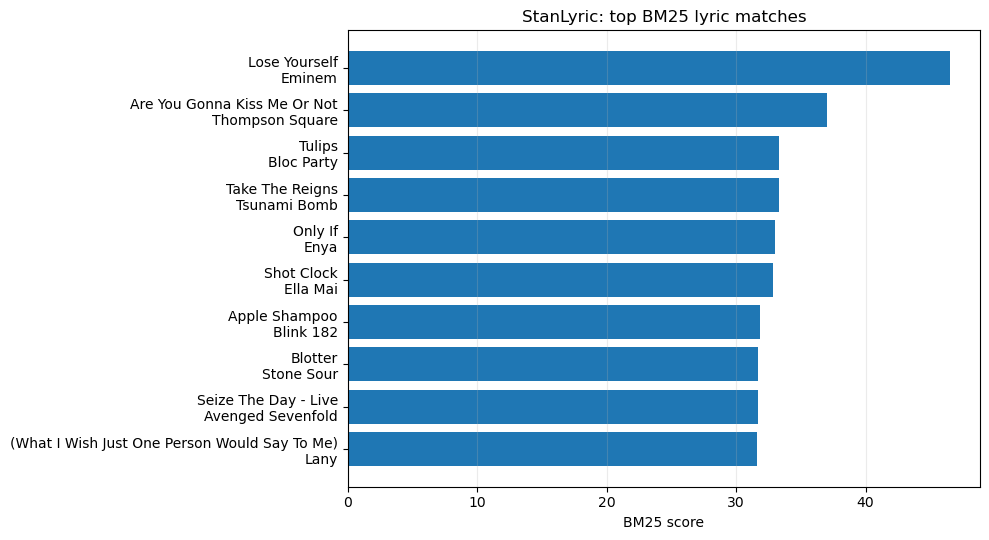

In [16]:
plot_top_scores(results[display_cols], title="StanLyric: top BM25 lyric matches");

## 8. Evaluate BM25 retrieval
We create synthetic queries by sampling lyric fragments from known songs, then measure whether BM25 retrieves the source song.

In [17]:
""" the evaluation protocol from the portfolio stanlyric demo
The evaluation protocol samples contiguous lyric fragments from known songs, hides the song identity, retrieves the top candidates, and 
measures whether the correct song appears in the top ranks. The metrics include Hit@1, Hit@5, MRR@10, and NDCG@10. 
With one known relevant song per query, Recall@k is equivalent to Hit@k, but both are useful for connecting the project to standard retrieval terminology.
"""

' the evaluation protocol from the portfolio stanlyric demo\nThe evaluation protocol samples contiguous lyric fragments from known songs, hides the song identity, retrieves the top candidates, and \nmeasures whether the correct song appears in the top ranks. The metrics include Hit@1, Hit@5, MRR@10, and NDCG@10. \nWith one known relevant song per query, Recall@k is equivalent to Hit@k, but both are useful for connecting the project to standard retrieval terminology.\n'

In [18]:
evaluator = RetrievalEvaluator(engine)
metrics, details, synthetic_queries = evaluator.evaluate_synthetic(
    EvalConfig(n_queries=200, min_query_tokens=5, max_query_tokens=18, top_k=10, random_state=42)
)
metrics

Evaluating retrieval: 100%|██████████| 200/200 [01:03<00:00,  3.15it/s]


,n_queries,hit@1,hit@3,hit@5,hit@10,recall@10,mrr@10,ndcg@10,median_rank_found,miss_rate@10
0,200,0.71,0.805,0.84,0.87,0.87,0.766107,0.791529,1.0,0.13


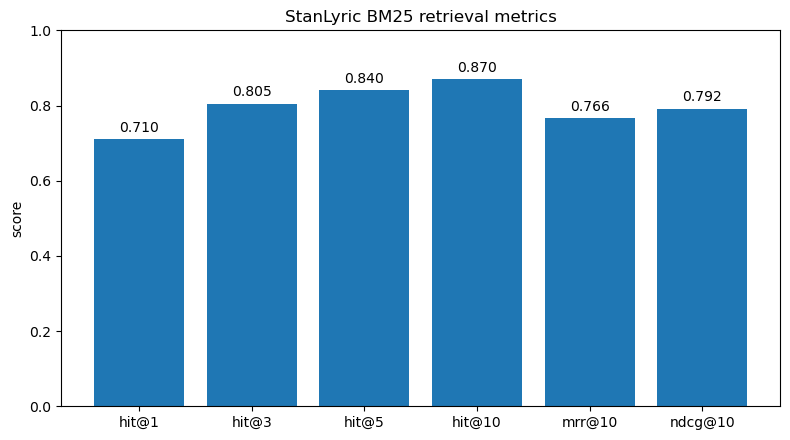

In [19]:
plot_metric_summary(metrics);

In [20]:
details.head(20)

,query,target_doc_id,target_title,target_artist,rank,found_in_top_k,top_prediction,top_artist,top_doc_id,top_score
0,yeah you pass me in the hallway but you ain't ...,song_0007646,I Just Wanna Know,Nf,1.0,True,I Just Wanna Know,Nf,song_0007646,58.371628
1,laughing while the mad dog,song_0023516,Fingers Of Love,Crowded House,2.0,True,Mad Dog,Deep Purple,song_0019227,27.357246
2,nation we don't know we don't know for me,song_0009240,Time Is Ticking Out,The Cranberries,4.0,True,Rhythm Nation,Janet Jackson,song_0019980,20.683357
3,to be it's something that is oh so,song_0026280,Natural,S Club,1.0,True,Natural,S Club,song_0026280,29.764606
4,way in this great future you can't forget your...,song_0004082,No Woman No Cry,Boney M.,4.0,True,"No Woman, No Cry - L.P. Version",Fugees,song_0008026,55.687370
5,on the inside diamonds diamonds like a soldier...,song_0027148,Diamonds On The Inside,Ben Harper,1.0,True,Diamonds On The Inside,Ben Harper,song_0027148,68.773743
6,he cried no money could save,song_0009059,Lucky Man.2,"Emerson, Lake & Palmer",2.0,True,Lucky Man (2012 Stereo Mix),"Emerson, Lake & Palmer",song_0032898,19.474560
7,mistakes sell me out the,song_0007947,My Heart Is The Worst Kind Of Weapon,Fall Out Boy,NaN,False,Fake Id,Big & Rich Feat. Gretchen Wilson,song_0033743,20.123539
8,fate shouldve made you a gentlemans,song_0036354,Amanda,Don Williams,1.0,True,Amanda,Don Williams,song_0036354,61.575687
9,got my pictures on the wall in your,song_0035378,Beautiful,Snoop Dogg,NaN,False,Now Youre Gone,Basshunter,song_0006748,35.913242


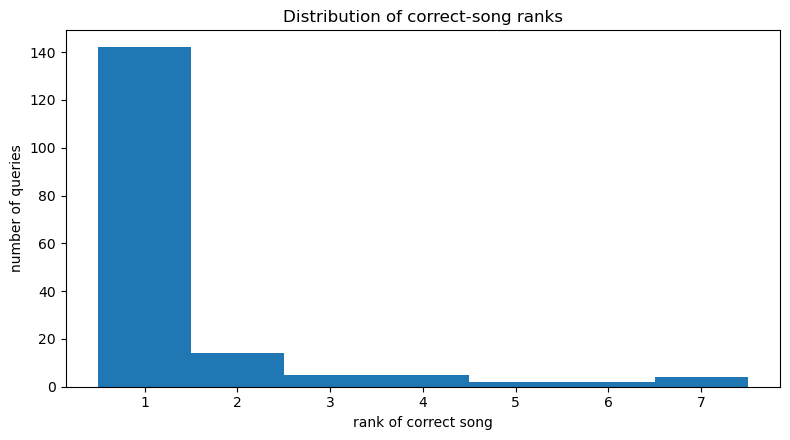

In [21]:
if details["rank"].notna().any():
    plot_rank_distribution(details);

## Next upgrades
1. Add typo/noise robustness queries.
2. Add character n-gram TF-IDF for misremembered lyrics.
3. Add dense embeddings and hybrid BM25 + dense reranking.
4. Connect retrieved songs to Spotify playlist/liked-track metadata.